# Lab 12: Solving POMDPs



## Reminder: definitition of a POMDP problem

Discrete sets of:
- States: $S$
- Actions: $A$  -- subtle point: unlike in MDPs, all states have the same set of actions! Otherwise the states are distinguishable.
- Observations: $O$ -- provide incomplete and/or noisy state information.

Parametrized by:
- Reward function: $R(s,a)$
- Observation probability function: $\Omega(o,s,a) := Pr(o_{t+1} = o | a_t = a, s_{t+1} = s)$
- Transition probability function: $T(s,a,s') := Pr(s_{t+1} = s' | a_t = a, s_t = s)$
- Discount factor $\gamma \in (0, 1)$.
- Initial belief point (or also called belief state) $b_0 \in \Delta(S)$

**Goal**: maximize the expected discounted sum of rewards $\mathbb{E} \left[\sum_t \gamma^t R(s_t, a_t)\right]$

Q: Geometrically, what is $\Delta(S)$ ?



In [1]:
import itertools
import math
from copy import deepcopy
from typing import List, Tuple

import numpy as np

from IPython.display import display, HTML

We will translate this formalism into code and try to maximize similarity with theoretical notation.

The following code is somewhat similar to the one we had in Lab 3.

In [2]:
# Tip: Keep this code pinned in Colab.

Action = str
Observation = str
State = str


class TransitionModel:
    # Returns T(s, a, s') = Pr(s'|s,a) = Pr(state2|state1,action)
    def probability(self, s: State, a: Action, s_next: State) -> float: NotImplementedError()

    # Sample next state s' according to T(s,a,s').
    def sample(self, s: State, a: Action) -> State:                 NotImplementedError()


class RewardModel:
    # Models the reward distribution Pr(r|s,a).
    # We will simplify the problem to use only deterministic rewards: R(s,a)
    def sample(self, s: State, a: Action) -> float:                 NotImplementedError()


# Models distribution O(o,s,a) = Pr(o|s,a)
class ObservationModel:
    # We will simplify the problem to use only observations
    # independent of actions: Pr(o|s,a) = Pr(o|s)
    def probability(self, observation, next_state, action=None) -> float:  NotImplementedError()

    # Produce an observation for the current state according to Pr(o|s)
    def sample(self, state) -> Observation:                         NotImplementedError()


class POMDP:
    def states(self) -> List[State]:                                NotImplementedError()
    def actions(self) -> List[Action]:                              NotImplementedError()
    def observations(self) -> List[Observation]:                    NotImplementedError()
    def transition_model(self) -> TransitionModel:                  NotImplementedError()
    def reward_model(self) -> RewardModel:                          NotImplementedError()
    def observation_model(self) -> ObservationModel:                NotImplementedError()
    def init_beliefs(self) -> np.array:                             NotImplementedError()
    def discount(self) -> float:                                    NotImplementedError()

## Task 1: Formalize a very simple POMDP.



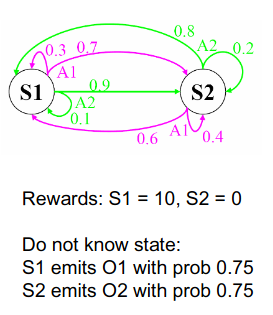

In [3]:
class SimplePOMDP(POMDP):
    # Let's parametrize the POMDP with obs_prob
    def __init__(self, obs_prob=0.75):
        self.obs_prob = obs_prob

    def states(self) -> List[State]:
        return ["S1", "S2"]

    def actions(self) -> List[Action]:
        return ["A1", "A2"]

    def observations(self) -> List[Observation]:
        return ["O1", "O2"]

    def transition_model(self) -> TransitionModel:      return SimpleTM()
    def reward_model(self) -> RewardModel:              return SimpleRM()
    def observation_model(self) -> ObservationModel:    return SimpleOM(self.obs_prob)
    def init_beliefs(self) -> np.array:                 return np.array([0.5, 0.5])
    def discount(self) -> float:                        return 0.9


class SimpleTM(TransitionModel):
    _TRANSITIONS_TABLE = {  # Table T(s,a,s')
        ("S1", "A1", "S1"): 0.3, ("S1", "A1", "S2"): 0.7,
        ("S1", "A2", "S1"): 0.1, ("S1", "A2", "S2"): 0.9,
        ("S2", "A1", "S1"): 0.6, ("S2", "A1", "S2"): 0.4,
        ("S2", "A2", "S1"): 0.8, ("S2", "A2", "S2"): 0.2,

    }

    def probability(self, s: State, a: Action, next_s: State) -> float:
        return self._TRANSITIONS_TABLE[(s, a, next_s)]

    def sample(self, state: State, action: Action) -> State:
        next_states_and_probs = [
            (s2, prob) for (s1, a, s2), prob in self._TRANSITIONS_TABLE.items()
            if s1 == state and a == action
        ]
        probs = [p for s, p in next_states_and_probs]
        idx = np.random.choice(len(next_states_and_probs), p=probs)
        next_s, prob = next_states_and_probs[idx]
        return next_s


class SimpleRM(RewardModel):
    _REWARDS_TABLE = {
        "S1": 10, "S2": 0
    }

    def sample(self, state: State, action: Action) -> float:
        return self._REWARDS_TABLE[state]


# Models distribution O(o,s,a) = Pr(o|s,a)
class SimpleOM(ObservationModel):
    def __init__(self, obs_prob):
        self._OBSERVATIONS_TABLE = {
            ("S1", "O1"): obs_prob, ("S1", "O2"): 1 - obs_prob,
            ("S2", "O1"): 1 - obs_prob, ("S2", "O2"): obs_prob,
        }

    def probability(self, observation: Observation, next_state: State, action=None) -> float:
        return self._OBSERVATIONS_TABLE[(next_state, observation)]

    def sample(self, state: State) -> Observation:
        next_obs_and_probs = [
            (obs, prob) for (s1, obs), prob in self._OBSERVATIONS_TABLE.items()
            if s1 == state
        ]
        probs = [p for o, p in next_obs_and_probs]
        idx = np.random.choice(len(next_obs_and_probs), p=probs)
        next_obs, prob = next_obs_and_probs[idx]
        return next_obs

## Task 2: Derivation of belief update $b_{t+1}$ based on $b_{t}$

Based on https://www.cs.cmu.edu/~ggordon/780-fall07/lectures/POMDP_lecture.pdf

The POMDP model assumes agent first acts and then receives observations.

Q: Express belief state $b_1(s)$ at time $t=1$ using a conditional probability. What is a "reasonable" conditioning?



Q: Generalize the belief state to time $t$, i.e. write a formula for $b_t(s)$ given previous time step.



Q: Write $b_t$ as an update based on $b_{t-1}$.



Q: Given a current belief $b_t$, taking an action $a_t$ and observing $o_{t+1}$, how can we compute new belief $b_{t+1}$ Express in terms of $\Omega$ and $T$.



Q: Given the simple env from before, what will be the belief after the first step, if we took action A1 and received observation O1 ? (We start with uniform belief)

In [ ]:
o_s = np.array([
    # O(O1,S1,A1)
    0.75,
    # O(O1,S2,A1)
    0.25
])

s_ab = np.array([
    # T(S1,A1,S1) * B(S1) + T(S2,A1,S1) * B(S2)
    0.3 * 0.5 + 0.6 * 0.5,
    # T(S1,A1,S2) * B(S1) + T(S2,A1,S2) * B(S2)
    0.7 * 0.5 + 0.4 * 0.5
])

o_ab = np.sum(o_s * s_ab)

new_belief_point = o_s * s_ab / o_ab
print(new_belief_point)

[0.71052632 0.28947368]


## Task 3: Implement beliefs update based on the mathematical derivation.

Implement the belief update $b_{t+1}$ based on $b_t$, action $a_t$ and observation $o_{t+1}$

In [ ]:
def belief_point_update(env: POMDP, a: Action, o: Observation, bs: np.array) -> np.array:
    # We will make all computation vectorized over all the environment states at once.
    states = env.states()

    # Pr(o|s,a) = Pr(o|s)  in our examples
    o_s = np.array([env.observation_model().probability(o, s) for s in states])

    # Pr(s'|a,b) -- we call s' = next_s
    s_ab = np.zeros(len(states))
    for i, next_s in enumerate(states):
        trans_probs = np.array(
            [env.transition_model().probability(s, a, next_s) for s in states])  # T(s, a, s')
        s_ab[i] = np.sum(trans_probs * bs)

    # Pr(o|a,b)
    o_ab = np.sum(o_s * s_ab)
    assert o_ab > 0

    new_bs = o_s * s_ab / o_ab

    # Updated beliefs must be a valid probability distribution.
    assert abs(sum(new_bs) - 1.0) < 1e-8
    return new_bs

Q: How can we test the beliefs update?



In [ ]:
def test_belief_point_update():
    env = SimplePOMDP(obs_prob=1)
    a = "A1"
    o = "O1"

    bs = env.init_beliefs()
    new_bs = belief_point_update(env, a, o, bs)
    assert np.allclose(new_bs, [1, 0])

    env = SimplePOMDP(obs_prob=0)
    bs = env.init_beliefs()
    new_bs = belief_point_update(env, a, o, bs)
    assert np.allclose(new_bs, [0, 1])

    env = SimplePOMDP()
    bs = env.init_beliefs()
    new_bs = belief_point_update(env, a, o, bs)
    assert np.allclose(new_bs, [0.71052632, 0.28947368])

test_belief_point_update()

### Belief updates when agent is making random choices in the env

Let's see how beliefs are changing when we make a random trajectory of actions and observations through the environment.

In [ ]:
# Helper code to create trajectory tables.

def make_trajectory(env: POMDP, initial_state: State, traj_len: int = 5) \
    -> Tuple[List[State], List[Action], List[Observation], List[np.array]]:

    state = initial_state
    bs = env.init_beliefs()
    obs = None

    action_trajectory = []
    state_trajectory = []
    obs_trajectory = []
    beliefs_trajectory = []

    for _ in range(traj_len):
        action = np.random.choice(env.actions())
        action_trajectory.append(action)
        state_trajectory.append(state)
        obs_trajectory.append(obs)
        beliefs_trajectory.append(bs.copy())

        state = env.transition_model().sample(state, action)
        obs = env.observation_model().sample(state)
        bs = belief_point_update(env, action, obs, bs)

    state_trajectory.append(state)
    obs_trajectory.append(obs)
    beliefs_trajectory.append(bs.copy())

    return state_trajectory, action_trajectory, obs_trajectory, beliefs_trajectory


def show_trajectory(env: POMDP,
                    state_trajectory: List[State],
                    action_trajectory: List[Action],
                    obs_trajectory: List[Observation],
                    beliefs_trajectory: List[np.array]):
    traj_len = len(state_trajectory) - 1

    mostly_correct = [np.argmax(b) == env.states().index(s)
                      for b, s in zip(beliefs_trajectory, state_trajectory)]
    correct_perc = np.cumsum(mostly_correct) / np.arange(1, traj_len + 2)

    out = "<table border='1' cellspacing='3' cellpadding='3' style='border:1px solid #000; border-collapse: collapse'>"
    out += "<tr>"
    out += "".join([f"<th>{col}</th>" for col in
                    ["time", "obs ", "state", "action", "beliefs", "correct",
                     "correct %"]])
    out += "</tr>"
    for t, s, a, o, bs, c, p in zip(range(traj_len + 1), state_trajectory,
                                    action_trajectory, obs_trajectory,
                                    beliefs_trajectory, mostly_correct, correct_perc):
        out += "<tr>"
        out += "".join([f"<td><pre>{col}</pre></td>" for col in
                        [t, o, s, a, "["+", ".join(f"{b:.2f}" for b in bs)+"]", c, f"{p:.2f}"]])
        out += "</tr>"
    return HTML(out)

Let's keep track of whether the highest belief corresponds to the current state (it is "correct") and what is the percentage of past correct beliefs.

In [ ]:
# obs_prob=1 so we should immediately know where we are
env = SimplePOMDP(obs_prob=1)
display(show_trajectory(env, *make_trajectory(env, "S2", traj_len=10)))

time,obs,state,action,beliefs,correct,correct %
0,None,S2,A1,"[0.50, 0.50]",False,0.00
1,O1,S1,A1,"[1.00, 0.00]",True,0.50
2,O1,S1,A1,"[1.00, 0.00]",True,0.67
3,O2,S2,A2,"[0.00, 1.00]",True,0.75
4,O1,S1,A1,"[1.00, 0.00]",True,0.80
5,O2,S2,A2,"[0.00, 1.00]",True,0.83
6,O1,S1,A2,"[1.00, 0.00]",True,0.86
7,O2,S2,A1,"[0.00, 1.00]",True,0.88
8,O1,S1,A2,"[1.00, 0.00]",True,0.89
9,O2,S2,A1,"[0.00, 1.00]",True,0.90


In [ ]:
# More difficult POMDP
env = SimplePOMDP(obs_prob=0.75)
display(show_trajectory(env, *make_trajectory(env, "S2", traj_len=50)))

time,obs,state,action,beliefs,correct,correct %
0,None,S2,A1,"[0.50, 0.50]",False,0.00
1,O1,S1,A1,"[0.71, 0.29]",True,0.50
2,O2,S1,A1,"[0.17, 0.83]",False,0.33
3,O1,S2,A1,"[0.78, 0.22]",False,0.25
4,O1,S1,A2,"[0.63, 0.37]",True,0.40
5,O2,S2,A2,"[0.16, 0.84]",True,0.50
6,O2,S1,A1,"[0.43, 0.57]",False,0.43
7,O2,S2,A2,"[0.23, 0.77]",True,0.50
8,O1,S1,A1,"[0.84, 0.16]",True,0.56
9,O2,S2,A1,"[0.15, 0.85]",True,0.60


Q: Towards what value "correct %" converges to? Why?



# $\alpha$-vectors


Q: Why are POMDPs harder than MDPs?



Q: Suppose that you have some "suitable representation" of a value function for a given policy in POMDPs. But you don't know which state you are at. What is the relationship between the values and beliefs?



Q: What are $\alpha$-vectors?



Q: How do we use the set of alpha vectors to find the value of an optimal policy?



Q: How do we represent alpha vectors?



In [ ]:
AlphaVector = np.array


def make_alpha_vector(env: POMDP, action: Action) -> AlphaVector:
    """
    Make an alpha vector for one-step policy by following a single action.
    """
    num_states = len(env.states())
    alpha = np.zeros(num_states)

    # Make an initial approximation.
    for i in range(num_states):
        alpha[i] = env.reward_model().sample(env.states()[i], action)
    return alpha


def eval_belief_point(alpha_vectors: List[AlphaVector], belief_point: np.array):
    """
    Take a set of alpha vectors and take maximum for the given belief point.
    Return tuple (max value, argmax alpha_vector)
    """
    max = -math.inf
    best_alpha = None
    for alpha in alpha_vectors:
        v = np.dot(alpha, belief_point)
        if v > max:
            max = v
            best_alpha = alpha
    return max, best_alpha
    # Alternative solution: Put alpha_vectors into a matrix A, belief_point b,
    # multiply directly y=A*b, and return max(y), A[:, argmax(y)]

Q: What is an n-step horizon?



For the  tiger example from the lectures (3 actions, 2 observations):

Q: How many alpha vectors are there for i) first step, ii) second, or iii) third step of full value iteration?

i.e. what is the number of pure policies (where we choose an action with 100% probability) within the n-step horizon?



# Bonus: Robot Maze Env

Following is Maze implementation from Lab 3. We will wrap the implementation into our recent POMDP formalism, so we can use the maze in the same way as the simple pomdp.

In [ ]:
Action = str  # Type alias
Observation = str

class State:
    def __init__(self, maze_rows: List[str]):
        self._maze_rows = [list(row) for row in maze_rows]

        # Make sure the maze has a rectangular shape, and has a proper boundary.
        assert all(len(row) == self.num_cols() for row in self._maze_rows)
        assert set(self._maze_rows[0]) == {"#"} and set(self._maze_rows[-1]) == {"#"}
        assert all(row[0] == "#" and row[-1] == "#" for row in self._maze_rows)

    def actions(self) -> List[Action]:
        """
        :return: list of actions available at the current state.
        """
        return [
            "m",  # Move forward.
            "l",  # Turn left.
            "r",  # Turn right.
        ]

    def apply(self, action: Action) -> None:
        """
        Apply action in the current state.
        """
        i, j, direction = self.current_position()

        # Maze rows is a List, this makes a reference in Python, not a copy.
        m = self._maze_rows

        if action == 'm':
            movement_map = {
                '^': [-1,  0],
                'v': [ 1,  0],
                '<': [ 0, -1],
                '>': [ 0,  1]}
            di, dj = movement_map.get(direction)
            i_new = i + di
            j_new = j + dj

            if m[i_new][j_new] != "#":
                m[i][j], m[i_new][j_new] = " ", m[i][j]

        else: # Change direction
            direction_map = {
              "l": {"^": "<",   "<": "v",  "v": ">",   ">": "^"},
              "r": {"^": ">",   ">": "v",  "v": "<",   "<": "^"}, }
            new_direction = direction_map[action][direction]
            m[i][j] = new_direction

    def copy(self) -> "State":
        return State(deepcopy(self._maze_rows))

    # -- Maze specific methods ---------------------------------------------------

    def num_rows(self):
        return len(self._maze_rows)

    def num_cols(self):
        return len(self._maze_rows[0])

    def current_position(self) -> Tuple[int, int, str]:
        # Return agent coordinates and orientation.
        for i in range(self.num_rows()):
            for j in range(self.num_cols()):
                if self._maze_rows[i][j] in ["^", "<", "v", ">"]:
                    return i, j, self._maze_rows[i][j]
        raise RuntimeError(
            "Invalid maze: current position not found in: " + "\n".join(self._maze_rows)
        )

    def num_golds(self) -> int:
        golds = 0
        for i in range(self.num_rows()):
            for j in range(self.num_cols()):
                if self._maze_rows[i][j] == "G":
                    golds += 1
        return golds

    def has_any_gold(self) -> bool:
        return self.num_golds() > 0

    # -- Helper methods ----------------------------------------------------------

    def __str__(self):
        return "\n".join(["".join(row) for row in self._maze_rows])

    def __eq__(self, other):
        return self._maze_rows == other._maze_rows

    def __hash__(self):
        return hash(str(self))

    def __repr__(self):
        return str(self)




In [ ]:
def make_all_states(initial_state: State) -> List[State]:
    states = [initial_state]
    opened = [0]
    while len(opened) > 0:
        from_idx = opened.pop()
        state = states[from_idx]
        for action in state.actions():
            next_state = state.copy()
            next_state.apply(action)
            if not next_state.has_any_gold():
                continue
            if next_state in states:
                to_idx = states.index(next_state)
            else:
                # Not visited yet, add to open.
                states.append(next_state)
                to_idx = len(states) - 1
                opened.append(to_idx)
    return states

def make_all_observations():
    return [''.join(char) for char in itertools.product(['#', ' '], repeat=4)]


class MazePOMDP(POMDP):
    def __init__(self, maze: List[str]):
        initial_state = State(maze)
        self.all_states = make_all_states(initial_state)
        self.all_observations = make_all_observations()
    def states(self) -> List[State]:  return self.all_states
    def observations(self) -> List[Observation]:   return self.all_observations
    def actions(self) -> List[Action]:  return ["m", "r", "l"]
    def transition_model(self) -> TransitionModel:  return MazeTM()
    def reward_model(self) -> RewardModel: return MazeRM()
    def observation_model(self) -> ObservationModel: return MazeOM()
    def init_beliefs(self) -> np.array:
        return np.full((len(self.states()),), 1. / len(self.states()))
    def discount(self) -> float:
        return 0.9

class MazeRM(RewardModel):
    # Models the reward distribution Pr(r|s,a).
    # We will simplify the problem to use only deterministic rewards: R(s,a)
    def sample(self, state: State, action: Action) -> float:
        next_state = state.copy()
        next_state.apply(action)
        if next_state.num_golds() < state.num_golds():
            return 1
        elif state.num_golds() == 0:
            return 0
        elif action == "m":
            return -0.2
        else:
            return -0.1

# Models distribution O(o,s,a) = Pr(o|s,a)
class MazeOM(ObservationModel):
    # We will simplify the problem to use only observations
    # independent of actions: Pr(o|s,a) = Pr(o|s)
    def probability(self, observation: Observation, next_state: State, action=None) -> float:
        return 1.0 if self.sample(next_state) == observation else 0.0

    # Produce an observation for the current state according to Pr(o|s)
    def sample(self, state: State) -> Observation:
        # Agent looks around clockwise and returns string of 4 characters.
        observation_map = {
            '^': [[-1, 0], [0, 1], [1, 0], [0, -1]],
            '>': [[0, 1], [1, 0], [0, -1], [-1, 0]],
            'v': [[1, 0], [0, -1], [-1, 0], [0, 1]],
            '<': [[0, -1], [-1, 0], [0, 1], [1, 0]], }
        observation = []
        i, j, d = state.current_position()
        for o in observation_map[d]:
            i_new = i + o[0]
            j_new = j + o[1]
            ch = state._maze_rows[i_new][j_new]
            if ch == 'G':
                ch = ' '
            observation.append(ch)
        return ''.join(observation)


class MazeTM(TransitionModel):
    # Returns T(s, a, s') = Pr(s'|s,a) = Pr(state2|state1,action)
    def probability(self, state1: State, action: Action, state2: State) -> float:
        next_state = state1.copy()
        next_state.apply(action)
        if next_state == state2:
            if state1 == state2: return 1.0
            else:                return 0.9
        elif state1 == state2:   return 0.1
        else:                    return 0.0

    # Sample next state s' according to T(s,a,s').
    def sample(self, state: State, action: Action) -> State:
        r = np.random.uniform(0.0, 1.0)
        if r < 0.1:
            return state.copy()
        else:
            next_state = state.copy()
            next_state.apply(action)
            return next_state

In [ ]:
env = MazePOMDP(["#####",
                 "#  G#",
                 "# # #",
                 "#^  #",
                 "#####"])
print("Num states", len(env.states()))
print("Num observations", len(env.observations()))
print("Num actions", len(env.actions()))


Q:

  * How many alpha vectors are there for first step full value iteration?
  * How many alpha vectors are there for second step full value iteration?





Clearly, storing all alpha vectors is really impractical. We can bound the number of alpha vectors by randomly sampling and storing only |B| alpha-vectors and perform **point-based value updates**.


## Point-based value updates

Reminder from lectures: value iteration for POMDPs:

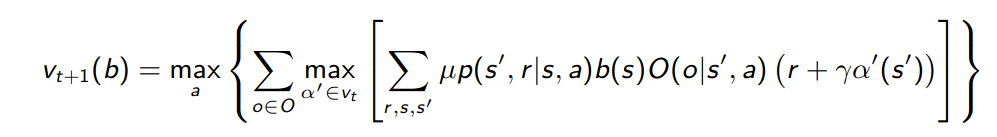

We are going to implement point-based value updates, i.e. running value iteration only at selected belief points.

Q: How do we choose which belief points to use?



Steps:

1. For a given belief point $b$, we want to evaluate how good is each action -> what is the expected reward if an action is played.

2. Therefore, we need to account for all possible beliefs $\{b'_0, \ldots, b'_k \}$ that can be reached after playing some action (note that there can be multiple belief points due to possible different outcomes of the actions and/or different received observations).
3. For each $b'_i$, we will choose the best action according to the current alpha vectors and compute the value for this belief point $b'_i$.
4. In order to compute expected reward, we need to weight rewards for belief points $b'_i$ by probability that these belief points will actually be reached.

In [ ]:
BeliefsWithProbs = Tuple[np.array, Observation, float]


def next_belief_points(env: POMDP, belief_point: np.array, a: Action) -> BeliefsWithProbs:
    """
    Returns list of triplets (new_belief, obsevation, probability of this observation)
    i.e. list of possible beliefs with observations and probability that the
    beliefs will be actually reached when the action is played in the belief_point.

    This essentially computes the same thing as belief_point_update, for each possible observation.
    """
    next_points = []
    for o in env.observations():
        o_prob = 0.0
        for s_idx, s in enumerate(env.states()):
            for ns in env.states():
                tp = env.transition_model().probability(s, a, ns)
                op = env.observation_model().probability(o, ns)
                o_prob += op * tp * belief_point[s_idx]

        if o_prob > 0:
            next_points.append(
                (belief_point_update(env, a, o, belief_point), o, o_prob))
    return next_points


In [ ]:
def expected_reward_for_action(env: POMDP, belief_point: np.array, action: Action) -> float:
    """
    Return the expected reward after taking one action in the current belief point.
    """
    v = 0.0
    for s_idx, s in enumerate(env.states()):
        if belief_point[s_idx] == 0:
            continue
        # This is expected reward, because R(s,a) sampling here is deterministic.
        v += env.reward_model().sample(s, action) * belief_point[s_idx]
    return v


def compute_new_alpha_vector(env: POMDP,
                             alpha_vectors: List[AlphaVector],
                             belief_point: np.array,
                             next_beliefs_for_action: List[BeliefsWithProbs],
                             best_action: Action,
                             ) -> AlphaVector:
    new_alpha_vector = make_alpha_vector(env, best_action)
    for s_idx, s in enumerate(env.states()):
        if belief_point[s_idx] == 0:
            continue

        for ns_idx, next_s in enumerate(env.states()):
            if env.transition_model().probability(s, best_action, next_s) == 0:
                continue

            o = env.observation_model().sample(next_s)
            for next_belief_point, next_o, next_o_prob in next_beliefs_for_action:
                if next_o != o:
                    continue
                _, max_alpha = eval_belief_point(alpha_vectors, next_belief_point)
                tp = env.transition_model().probability(s, best_action, next_s)
                new_alpha_vector[s_idx] += env.discount() * max_alpha[ns_idx] * tp

    return new_alpha_vector


def point_based_value_update(env: POMDP,
                             alpha_vectors: List[AlphaVector],
                             belief_point: np.array) -> Tuple[float, Action, AlphaVector]:
    best_action = None
    max_action_value = -math.inf
    next_beliefs_for_best_action = None

    for a in env.actions():
        action_value = expected_reward_for_action(env, belief_point, a)
        next_beliefs = list(next_belief_points(env, belief_point, a))
        for next_belief_point, _, next_o_prob in next_beliefs:
            max_value, _ = eval_belief_point(alpha_vectors, next_belief_point)
            action_value += env.discount() * max_value * next_o_prob
        if action_value > max_action_value:
            best_action = a
            max_action_value = action_value
            next_beliefs_for_best_action = next_beliefs

    new_alpha_vector = compute_new_alpha_vector(env, alpha_vectors, belief_point,
                                                next_beliefs_for_best_action, best_action)
    return max_action_value, best_action, new_alpha_vector


Example for evaluation of the point-based value update. Let's have an initial state:
```
state1 = Maze([
     "#####",
     "#  G#",
     "# #<#",
     "#   #",
     "#####"])
```
and an initial belief such that agent considers that two states are equally possible -- the starting state and then the state:
```
 state2 = Maze([
     "#####",
     "# ^G#",
     "# # #",
     "#   #",
     "#####"])
```

Clearly, for both states it is optimal to turn right and go to the goal. We want this 2-step optimal plan to be found by the point-based value updates.

In [ ]:
env = MazePOMDP(["#####",
                 "#  G#",
                 "# #<#",
                 "#   #",
                 "#####"])

initial_belief = np.zeros(len(env.states()))
initial_belief[0] = 0.5
initial_belief[25] = 0.5

In [ ]:
# Let's check we set the distribution correctly:
def print_non_zero_states(env: POMDP, belief_point: np.array):
    all_states = env.states()
    for i in range(len(all_states)):
        if belief_point[i] > 0:
            print(all_states[i], "\n")

print_non_zero_states(env, initial_belief)

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "monospace"

def prep_alphas(alphas):
    out = []
    idx = 0

    for a in env.actions():
        out.append((a, alphas[idx]))
        idx += 1
    return out

def compute_y(alpha, states):
    extreme_pointL = np.zeros(len(env.states()))
    extreme_pointL[states[0]] = 1.0
    extreme_pointR = np.zeros(len(env.states()))
    extreme_pointR[states[1]] = 1.0

    return [np.dot(alpha, extreme_pointL), np.dot(alpha, extreme_pointR)]


def display_alphas(alphas, states, max_action_value=None, belief=0.0):
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']
    linestyles = ['solid', 'solid', (0, (2, 3))]
    colors_to_use = [colors[2], colors[1], colors[0]]

    x = [0, 1]

    for a, alpha in alphas:
        idx = env.actions().index(a)
        y = compute_y(alpha, states)
        plt.plot(x, y, label=a, linestyle=linestyles[idx], color=colors_to_use[idx])

    plt.xticks(np.arange(min(x), max(x) + 0.1, 0.1))
    locs, labels = plt.xticks()
    for i in range(len(labels)):
        labels[i] = ''
    labels[0] = str(env.states()[states[0]])
    labels[5] = str(0.5)
    labels[-1] = str(env.states()[states[1]])
    plt.xticks(locs, labels)
    plt.yticks()

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())

    idx = len(env.actions()) - 1
    if max_action_value is not None:
        plt.axvline(x=belief, color=colors[idx+1], linestyle='dotted')
        plt.axhline(y=max_action_value, color=colors[idx+2], linestyle='dotted')

    plt.xlabel('Belief of not being in the initial state')
    plt.ylabel('Value')

In [ ]:
initial_alphas = [make_alpha_vector(env, a) for a in env.actions()]
initial_val, initial_choice = eval_belief_point(initial_alphas, initial_belief)

print("Initial value: ", initial_val)

nonzero_states = [i for i in range(len(env.states())) if initial_belief[i] > 0]
preped_alphas = prep_alphas(initial_alphas)
display_alphas(preped_alphas, nonzero_states)

After performing the point based value update and adding the new alpha vector, the value is updated and the correct action is identified as optimal.

In [ ]:
max_action_value, best_action, new_alpha_vector = point_based_value_update(env, initial_alphas, initial_belief)
print("Max action value: ", max_action_value)
print("Best action: ", best_action)

preped_alphas.append((best_action, new_alpha_vector))
display_alphas(preped_alphas, nonzero_states, max_action_value, initial_belief[nonzero_states[1]])

In [ ]:
initial_belief2 = np.zeros(len(env.states()))
initial_belief2[0] = 0.5
initial_belief2[27] = 0.5

print_non_zero_states(env, initial_belief2)

In [ ]:
initial_alphas2 = [make_alpha_vector(env, a) for a in env.actions()]
initial_val, initial_choice = eval_belief_point(initial_alphas2, initial_belief2)

print("Initial value: ", initial_val)

nonzero_states2 = [i for i in range(len(env.states())) if initial_belief2[i] > 0]
preped_alphas2 = prep_alphas(initial_alphas2)
display_alphas(preped_alphas2, nonzero_states2)

In [ ]:
max_action_value, best_action, new_alpha_vector = point_based_value_update(env, initial_alphas2, initial_belief2)
print("Max action value: ", max_action_value)
print("Best action: ", best_action)

preped_alphas2.append((best_action, new_alpha_vector))
display_alphas(preped_alphas2, nonzero_states2, max_action_value, initial_belief2[nonzero_states2[1]])